In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv("Spam_SMS.csv", sep=',', names=['label', 'msg'])
data

,label,msg
0,Class,Message
1,ham,"Go until jurong point, crazy.. Available only ..."
2,ham,Ok lar... Joking wif u oni...
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...
4,ham,U dun say so early hor... U c already then say...
...,...,...
5570,spam,This is the 2nd time we have tried 2 contact u...
5571,ham,Will ü b going to esplanade fr home?
5572,ham,"Pity, * was in mood for that. So...any other s..."
5573,ham,The guy did some bitching but I acted like i'd...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5575 entries, 0 to 5574
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5575 non-null   object
 1   msg     5575 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
data.isnull().sum()

label    0
msg      0
dtype: int64

In [5]:
#data.describe() 

In [6]:
data['label'] = data['label'].map({'ham':0,'spam': 1})
data

,label,msg
0,NaN,Message
1,0.0,"Go until jurong point, crazy.. Available only ..."
2,0.0,Ok lar... Joking wif u oni...
3,1.0,Free entry in 2 a wkly comp to win FA Cup fina...
4,0.0,U dun say so early hor... U c already then say...
...,...,...
5570,1.0,This is the 2nd time we have tried 2 contact u...
5571,0.0,Will ü b going to esplanade fr home?
5572,0.0,"Pity, * was in mood for that. So...any other s..."
5573,0.0,The guy did some bitching but I acted like i'd...


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
#%matplotlib inline

<Axes: xlabel='label', ylabel='count'>

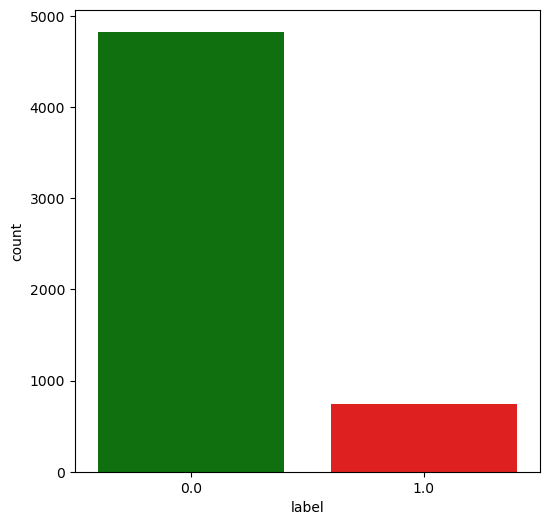

In [8]:
plt.figure(figsize=(6,6))
sns.countplot(x="label", hue="label", data=data,
                  palette=['green', 'red'], legend=False)
#p = plt.title('countplot for spam vs Ham as imbalanced dataset')
#p= plt.xlabel('Is the SMS Spam?')
#p=plt.ylabel('Count')

In [9]:
only_spam=data[data['label'] ==1]
for _ in range(int((len(data) - len(only_spam)) / len(only_spam))):
   data=pd.concat([data,only_spam])

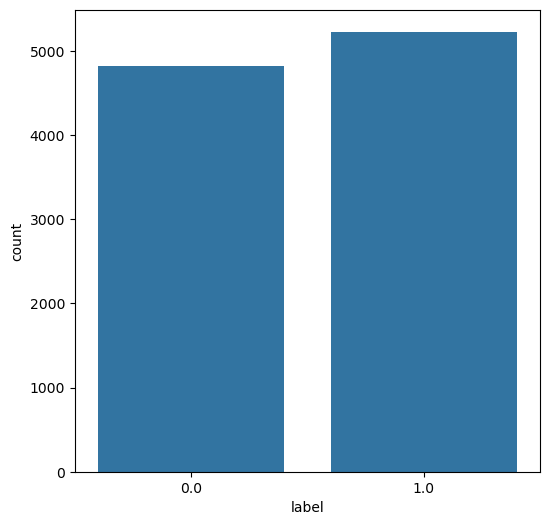

In [10]:
data = data.reset_index(drop=True)
data = data.loc[:, ~data.columns.duplicated()]

plt.figure(figsize=(6,6))
sns.countplot(x="label", data=data)
plt.show()

In [11]:
data['word_count'] = data['msg'].apply(lambda x: len(x.split()))
data

,label,msg,word_count
0,NaN,Message,1
1,0.0,"Go until jurong point, crazy.. Available only ...",20
2,0.0,Ok lar... Joking wif u oni...,6
3,1.0,Free entry in 2 a wkly comp to win FA Cup fina...,28
4,0.0,U dun say so early hor... U c already then say...,11
...,...,...,...
10052,1.0,Want explicit SEX in 30 secs? Ring 02073162414...,16
10053,1.0,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33
10054,1.0,Had your contract mobile 11 Mnths? Latest Moto...,28
10055,1.0,REMINDER FROM O2: To get 2.50 pounds free call...,28


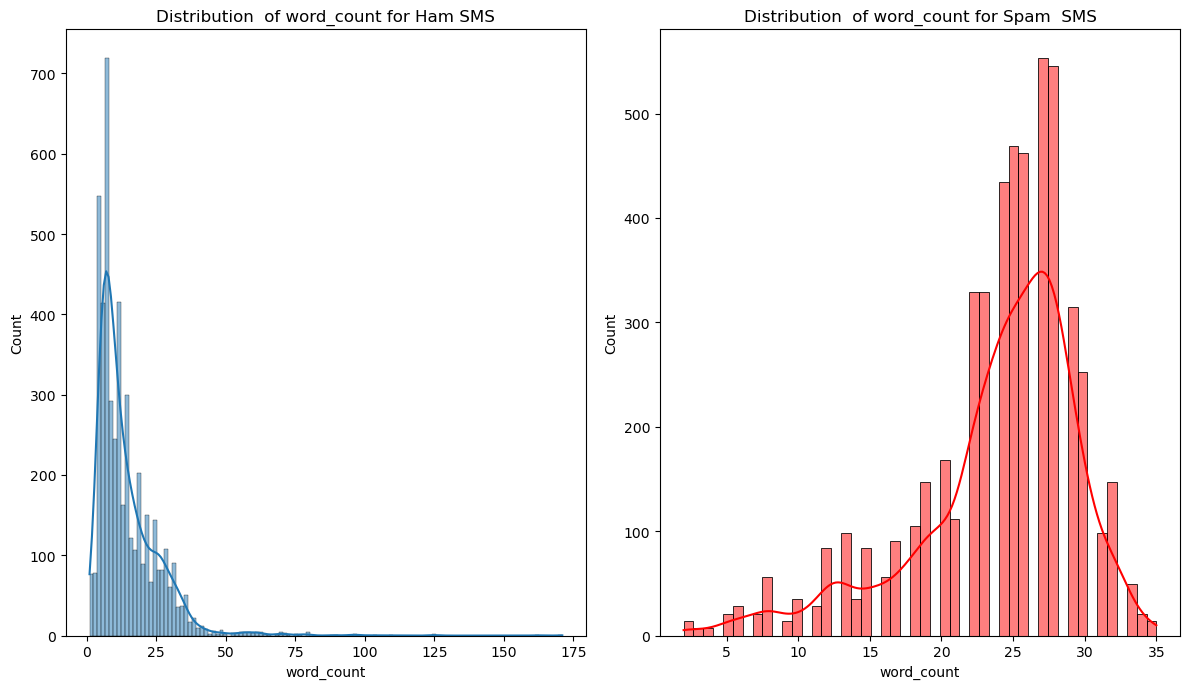

In [12]:
plt.figure(figsize=(12,7))
#(1,1)
plt.subplot(1,2,1)
g=sns.histplot(data[data["label"]== 0].word_count,kde=True)
p=plt.title('Distribution  of word_count for Ham SMS')

#(1,2)
plt.subplot(1,2,2)
g=sns.histplot(data[data["label"]== 1].word_count,color="red", kde=True)
p=plt.title('Distribution  of word_count for Spam  SMS')

plt.tight_layout()
plt.show()

In [13]:
def currency (data):
    curr_sym = ['€', '$', '¥', '£', '₹']
    for i in curr_sym:
       if i in data:
            return 1
    return 0

In [14]:
data['cur_sym']=data['msg'].apply(currency)
data

,label,msg,word_count,cur_sym
0,NaN,Message,1,0
1,0.0,"Go until jurong point, crazy.. Available only ...",20,0
2,0.0,Ok lar... Joking wif u oni...,6,0
3,1.0,Free entry in 2 a wkly comp to win FA Cup fina...,28,0
4,0.0,U dun say so early hor... U c already then say...,11,0
...,...,...,...,...
10052,1.0,Want explicit SEX in 30 secs? Ring 02073162414...,16,0
10053,1.0,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1
10054,1.0,Had your contract mobile 11 Mnths? Latest Moto...,28,0
10055,1.0,REMINDER FROM O2: To get 2.50 pounds free call...,28,0


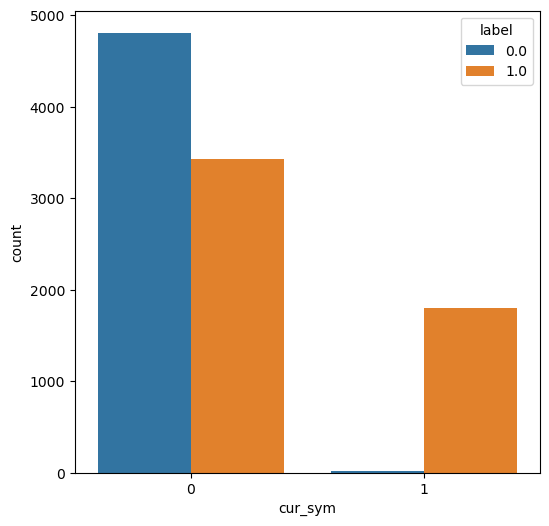

In [15]:
plt.figure(figsize=(6,6))
sns.countplot(x="cur_sym",data=data,hue='label')
plt.show()

In [16]:
def num(data):
    for i in data:
       if ord(i) >= 48 and ord(i) <= 57:
            return 1
    return 0

In [17]:
data['has_num']=data['msg'].apply(num)
data

,label,msg,word_count,cur_sym,has_num
0,NaN,Message,1,0,0
1,0.0,"Go until jurong point, crazy.. Available only ...",20,0,0
2,0.0,Ok lar... Joking wif u oni...,6,0,0
3,1.0,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,1
4,0.0,U dun say so early hor... U c already then say...,11,0,0
...,...,...,...,...,...
10052,1.0,Want explicit SEX in 30 secs? Ring 02073162414...,16,0,1
10053,1.0,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1,1
10054,1.0,Had your contract mobile 11 Mnths? Latest Moto...,28,0,1
10055,1.0,REMINDER FROM O2: To get 2.50 pounds free call...,28,0,1


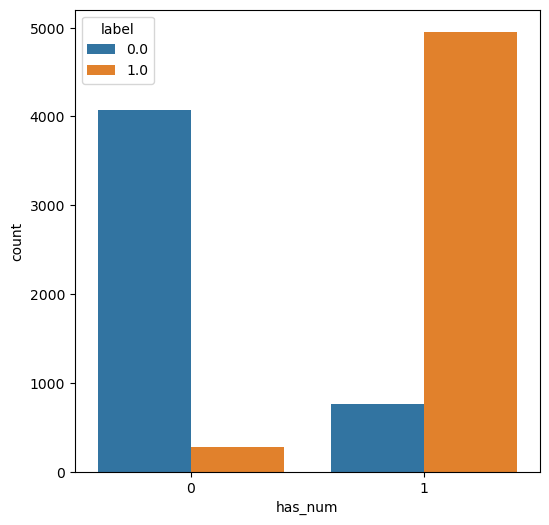

In [18]:
plt.figure(figsize=(6,6))
sns.countplot(x="has_num",data=data,hue='label')
plt.show()

In [19]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [20]:
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Alex\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alex\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
corpus = []
wnl = WordNetLemmatizer()

for sms in data.msg:
    msg = re.sub('[^a-zA-Z]', ' ', sms)
    msg = msg.lower()
    msg = [word for word in msg.split() if word not in set(stopwords.words('english'))]
    msg = [wnl.lemmatize(word) for word in msg]
    msg = ' '.join(msg)   # convert list back to sentence
    corpus.append(msg)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=500)
vectors=tfidf.fit_transform(corpus).toarray()
features =tfidf.get_feature_names_out()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [24]:
X=pd.DataFrame(vectors,columns=features)
X['word_count']=data['word_count'].values
X['has_num']=data['has_num'].values
X['cur_sym']=data['cur_sym'].values
y=data['label']

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [26]:
X_test

,ac,access,account,address,admirer,age,already,also,always,amp,...,yeah,year,yes,yet,yo,yr,yup,word_count,has_num,cur_sym
8330,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.411517,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,13,1,0
8244,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,17,0,0
1860,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,7,0,0
3888,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,11,0,0
10053,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.325152,0.0,0.0,0.0,0.0,33,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6687,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,20,1,0
7406,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,22,1,0
381,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,27,0,0
1734,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5,0,0


In [27]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.metrics import classification_report

In [28]:
# Remove rows with NaN in y_train
mask = ~np.isnan(y_train)
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]


In [29]:
model1 = SVC() 
model1.fit(X_train_clean, y_train_clean)
y_pred = model1.predict(X_test)
print("Model 1 Report:")
print(classification_report(y_test, y_pred))


model2 = LogisticRegression() 
model2.fit(X_train_clean, y_train_clean) 
y_pred2 = model2.predict(X_test)
print("Model 2 Report:")
print(classification_report(y_test, y_pred2))

Model 1 Report:
              precision    recall  f1-score   support

         0.0       0.93      0.86      0.90       988
         1.0       0.88      0.94      0.91      1024

    accuracy                           0.90      2012
   macro avg       0.91      0.90      0.90      2012
weighted avg       0.90      0.90      0.90      2012

Model 2 Report:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       988
         1.0       0.98      0.97      0.97      1024

    accuracy                           0.97      2012
   macro avg       0.97      0.97      0.97      2012
weighted avg       0.97      0.97      0.97      2012



In [30]:
print("y_train NaNs:", np.isnan(y_train).sum())
print("y_test NaNs:", np.isnan(y_test).sum())

y_train NaNs: 1
y_test NaNs: 0


In [31]:
mask_train = ~y_train.isna()

X_train = X_train[mask_train]
y_train = y_train[mask_train]

In [32]:
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
y_pred3=mnb.predict(X_test)
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94       988
         1.0       0.94      0.95      0.94      1024

    accuracy                           0.94      2012
   macro avg       0.94      0.94      0.94      2012
weighted avg       0.94      0.94      0.94      2012



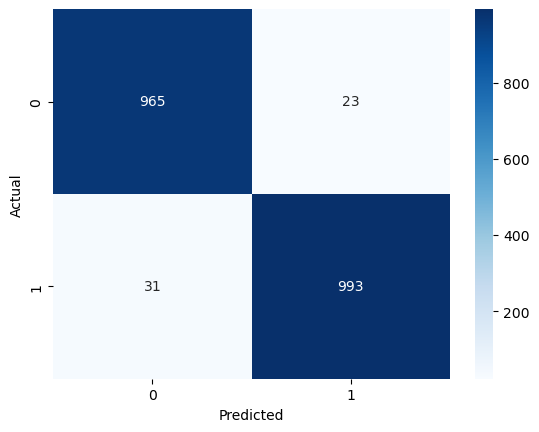

In [33]:
cm = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()